### Chart Generator — Password Cracking Analysis

In [39]:
# Step 1: Setup & Configuration

import csv, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

RESULTS_FILE = "results.csv"
OUTPUT_DIR   = "charts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

STRENGTH_COLORS = {
    "Very Weak" : "#e74c3c",
    "Weak"      : "#e67e22",
    "Medium"    : "#f1c40f",
    "Strong"    : "#2ecc71",
    "Very Strong": "#1abc9c",
}

def get_color(strength):
    return STRENGTH_COLORS.get(strength, "#95a5a6")

print("Setup complete.")

Setup complete.


In [40]:

# Step 2: Load Results

results = []
with open(RESULTS_FILE, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        row["attempts"]      = int(row["attempts"])
        row["time_seconds"]  = float(row["time_seconds"])
        row["cracked"]       = row["cracked"].lower() == "true"
        results.append(row)

print(f"Loaded {len(results)} results\n")
print(f"{'Password':<20} {'Strength':<12} {'Cracked':<10} {'Attempts':>10} {'Time(s)':>10}")
print("-"*65)
for r in results:
    print(f"{r['password']:<20} {r['strength']:<12} {str(r['cracked']):<10} {r['attempts']:>10,} {r['time_seconds']:>10}")

Loaded 7 results

Password             Strength     Cracked      Attempts    Time(s)
-----------------------------------------------------------------
abc                  Very Weak    True                1        0.0
daniel               Very Weak    True                1        0.0
danielsahid          Weak         False      321,272,406   195.9363
123456               Very Weak    True                1        0.0
password123          Medium       True                1        0.0
Malaysia2024         Strong       False      321,272,406   203.7547
x9#Lm!qZ2@kP         Strong       False      321,272,406   145.4417


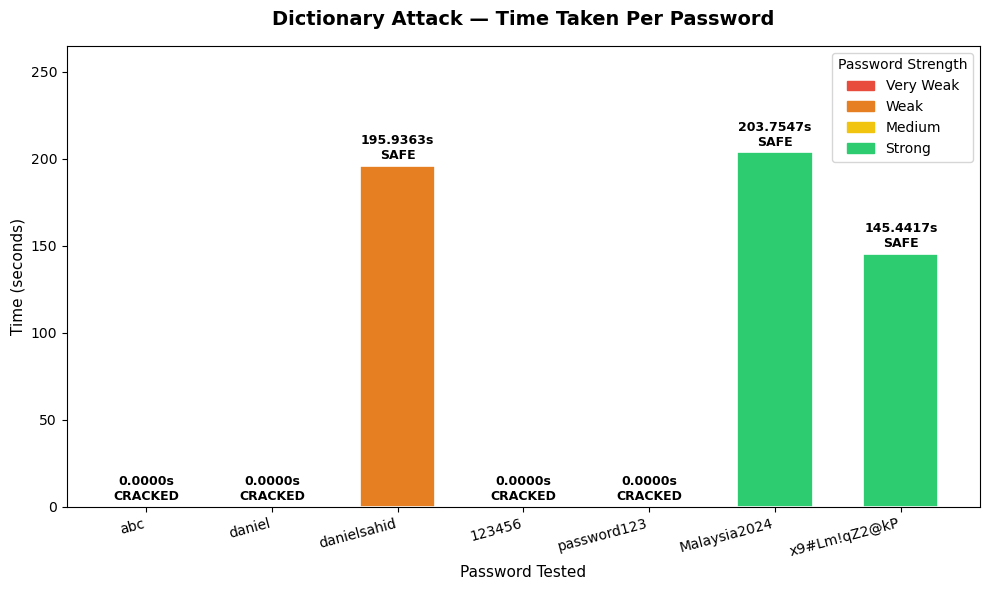

Saved: chart1_crack_time.png


In [41]:
# Step 3: Generate Chart 1 — Time Taken Per Password

labels  = [r["password"] for r in results]
times   = [r["time_seconds"] for r in results]
colors  = [get_color(r["strength"]) for r in results]
cracked = [r["cracked"] for r in results]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, times, color=colors, edgecolor="white", linewidth=1.2, width=0.6)

for bar, t, c in zip(bars, times, cracked):
    label  = f"{t:.4f}s"
    status = "CRACKED" if c else "SAFE"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
            f"{label}\n{status}", ha="center", va="bottom", fontsize=9, fontweight="bold")

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in STRENGTH_COLORS.items()
                  if k in [r["strength"] for r in results]]
ax.legend(handles=legend_patches, title="Password Strength")
ax.set_title("Dictionary Attack — Time Taken Per Password", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Password Tested", fontsize=11)
ax.set_ylabel("Time (seconds)", fontsize=11)
ax.set_ylim(0, max(times) * 1.3 if max(times) > 0 else 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart1_crack_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart1_crack_time.png")

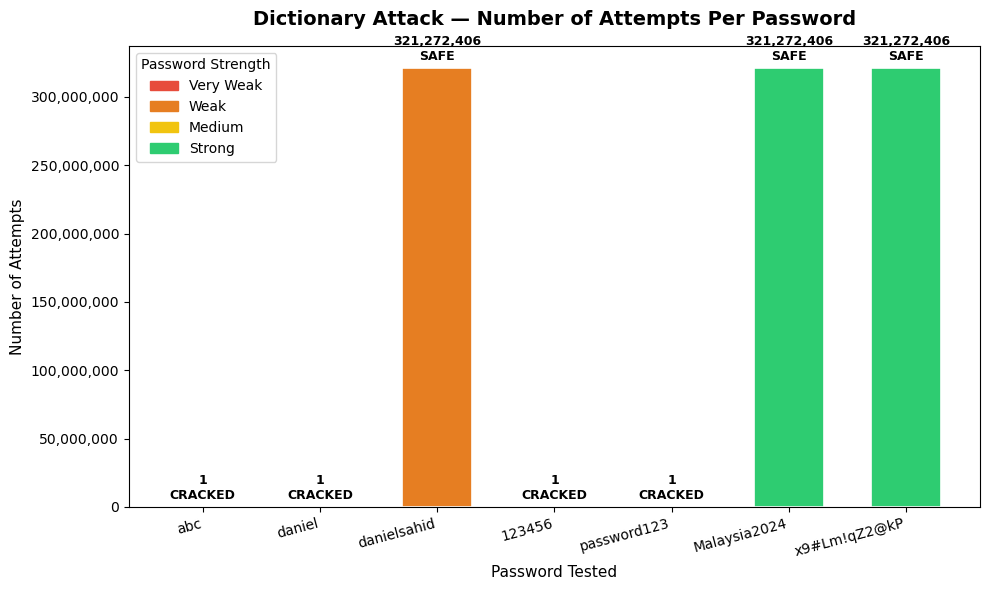

Saved: chart2_attempts.png


In [42]:
# Step 4: Generate Chart 2 — Number of Attempts Per Password

attempts_data = [r["attempts"] for r in results]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, attempts_data, color=colors, edgecolor="white", linewidth=1.2, width=0.6)

for bar, a, c in zip(bars, attempts_data, cracked):
    status = "CRACKED" if c else "SAFE"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(attempts_data)*0.01,
            f"{a:,}\n{status}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.legend(handles=legend_patches, title="Password Strength")
ax.set_title("Dictionary Attack — Number of Attempts Per Password", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Password Tested", fontsize=11)
ax.set_ylabel("Number of Attempts", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart2_attempts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart2_attempts.png")

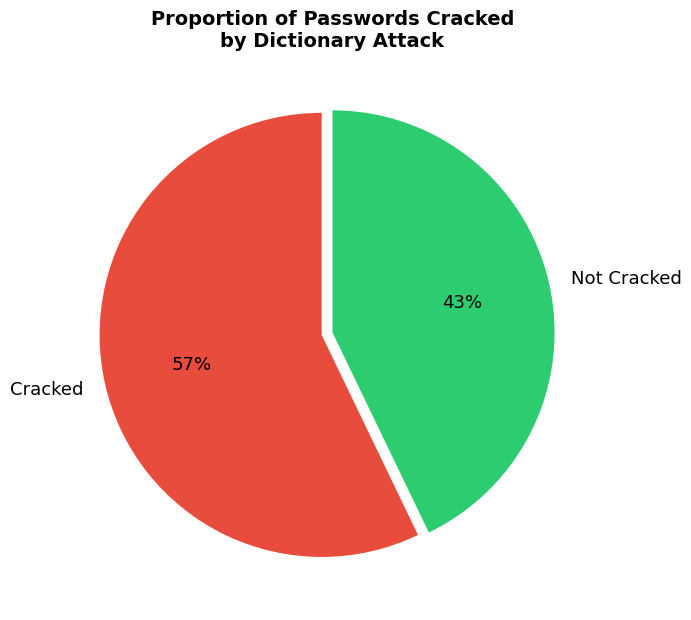

Saved: chart3_pie.png


In [43]:
# Step 3: Generate Chart 3 — Proportion of Passwords Cracked

cracked_count = sum(1 for r in results if r["cracked"])
safe_count    = len(results) - cracked_count

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie([cracked_count, safe_count],
       labels=["Cracked", "Not Cracked"],
       colors=["#e74c3c", "#2ecc71"],
       autopct="%1.0f%%", startangle=90, explode=(0.05, 0),
       textprops={"fontsize": 13})
ax.set_title("Proportion of Passwords Cracked\nby Dictionary Attack", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart3_pie.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart3_pie.png")

## 📊 Chart 4 — Password Strength vs Time to Crack

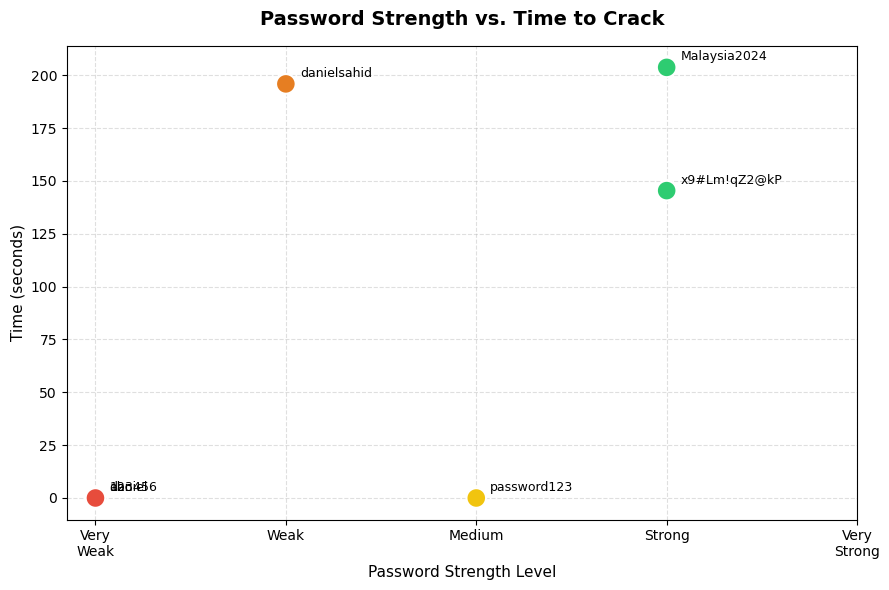

Saved: chart4_strength_vs_time.png


In [44]:
# Step 4: Generate Chart 4 — Password Strength vs. Time to Crack

strength_order = {"Very Weak": 1, "Weak": 2, "Medium": 3, "Strong": 4, "Very Strong": 5}

x = [strength_order.get(r["strength"], 3) for r in results]
y = [r["time_seconds"] for r in results]
c = [get_color(r["strength"]) for r in results]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, c=c, s=200, edgecolors="white", linewidth=1.5, zorder=3)

for xi, yi, r in zip(x, y, results):
    ax.annotate(r["password"], (xi, yi), textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["Very\nWeak", "Weak", "Medium", "Strong", "Very\nStrong"])
ax.set_title("Password Strength vs. Time to Crack", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Password Strength Level", fontsize=11)
ax.set_ylabel("Time (seconds)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart4_strength_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart4_strength_vs_time.png")